# 降维

降维是无监督学习中的核心主题之一。它的目标不是“简单删除特征”，而是在尽量保留信息的前提下，把高维数据映射到更低维的空间中。

这份笔记会按下面的顺序展开：
1. 先讲清楚降维的概念与数学原理
2. 再使用网页中的 PCA 与 t-SNE 示例代码做实际演示
3. 最后补一个手写 PCA 实现，帮助你把公式和代码对应起来

## 1. 降维的基本概念

### 什么是降维
降维（Dimensionality Reduction）就是把原始的高维数据映射到一个更低维的空间中，同时尽可能保留原始数据中的关键信息。

比如，一个样本原本有 100 个特征，降维后可能只保留 2 个、10 个或者 20 个“新特征”。这些新特征不是随便挑出来的，而是通过数学变换得到的。

### 为什么要降维
降维通常有四个主要目的：
1. 可视化：把高维数据压到二维或三维，便于观察结构。
2. 提升效率：减少特征数量后，训练和预测通常更快。
3. 去除冗余与噪声：很多原始特征彼此相关，信息重复。
4. 缓解维度灾难：维度太高时，样本会变得稀疏，距离度量和模型学习都会变难。

### 降维的核心思想
降维的本质是信息压缩，而不是粗暴丢弃数据。真正有价值的是：
- 保留尽可能多的方差信息
- 保留数据的局部结构或全局结构
- 让降维后的表示更适合后续分析或建模

## 2. 数学原理

### 2.1 方差与信息量
在 PCA 里，方差越大，通常表示这个方向上的数据变化越丰富，包含的信息越多。

对于一维数据 $x_1, x_2, \dots, x_n$，均值为：
$$
\mu = \frac{1}{n}\sum_{i=1}^{n} x_i
$$

方差为：
$$
\mathrm{Var}(x) = \frac{1}{n}\sum_{i=1}^{n}(x_i-\mu)^2
$$

### 2.2 协方差矩阵
如果数据有多个特征，那么就需要用协方差来描述特征之间的相关性。

对已经中心化的数据矩阵 $X \in \mathbb{R}^{n \times d}$，协方差矩阵可以写成：
$$
\Sigma = \frac{1}{n}X^TX
$$

其中：
- $n$ 是样本数
- $d$ 是特征数
- $\Sigma$ 是一个 $d \times d$ 的矩阵

协方差矩阵的对角线元素是各特征的方差，非对角线元素表示两个特征之间的相关程度。

### 2.3 特征值分解
PCA 的核心就是对协方差矩阵做特征值分解：
$$
\Sigma v = \lambda v
$$

其中：
- $v$ 是特征向量，表示新的坐标轴方向
- $\lambda$ 是特征值，表示该方向上的方差大小

把特征值从大到小排序，取前 $k$ 个对应的特征向量，就得到了前 $k$ 个主成分。

### 2.4 投影公式
假设选出的主成分组成投影矩阵 $W_k$，则原始数据投影到低维空间的公式为：
$$
Z = XW_k
$$

其中 $Z$ 就是降维后的表示。

### 2.5 PCA 的直观解释
PCA 做的事情可以概括为：
1. 让数据先中心化
2. 找到数据变化最剧烈的方向
3. 选择前几个最重要的方向
4. 把原始数据投影到这些方向上

这样既降低了维度，又尽量保留了原始数据的主要信息

## 3. 主流降维方法

### 3.1 PCA：主成分分析
PCA 是最经典的线性降维方法。它适合处理特征之间存在相关性的场景，目标是找到一组彼此正交的新坐标轴，使得：
- 第一主成分的方差最大
- 第二主成分在与第一主成分正交的前提下方差尽量大
- 以此类推

PCA 的优点：
- 原理清晰
- 计算效率高
- 适合做预处理和特征压缩

PCA 的局限：
- 本质是线性方法
- 对复杂非线性结构的表达能力有限

### 3.2 t-SNE：非线性降维
t-SNE 更适合做可视化。它不是特别强调“保留全局几何关系”，而是更关注局部邻域结构：
- 高维空间中相似的点，在低维空间中也尽量靠近
- 高维空间中不相似的点，在低维空间中尽量分开

t-SNE 的优点：
- 可视化效果通常很好
- 对簇结构展示能力强

t-SNE 的局限：
- 计算较慢
- 参数比较敏感
- 结果带有随机性
- 通常不用于后续建模，只适合探索和展示

## 4. 网页中的实例代码

下面的代码来自页面中的核心示例，并在此基础上补充了更清晰的注释。先看 PCA 在鸢尾花数据集上的二维可视化，再看 PCA 和 t-SNE 对非线性数据的表现差异。

原始数据形状: (150, 4)
降维后数据形状: (150, 2)
各主成分解释的方差比例: [0.92461872 0.05306648]


/home/zhiyinpeng/code/人工智能/AI-Learning/venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 31532 (\N{CJK UNIFIED IDEOGRAPH-7B2C}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/zhiyinpeng/code/人工智能/AI-Learning/venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 20108 (\N{CJK UNIFIED IDEOGRAPH-4E8C}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/zhiyinpeng/code/人工智能/AI-Learning/venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 20027 (\N{CJK UNIFIED IDEOGRAPH-4E3B}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/zhiyinpeng/code/人工智能/AI-Learning/venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 25104 (\N{CJK UNIFIED IDEOGRAPH-6210}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/zhiyinpeng/code/人工智能/AI-Learning/venv/

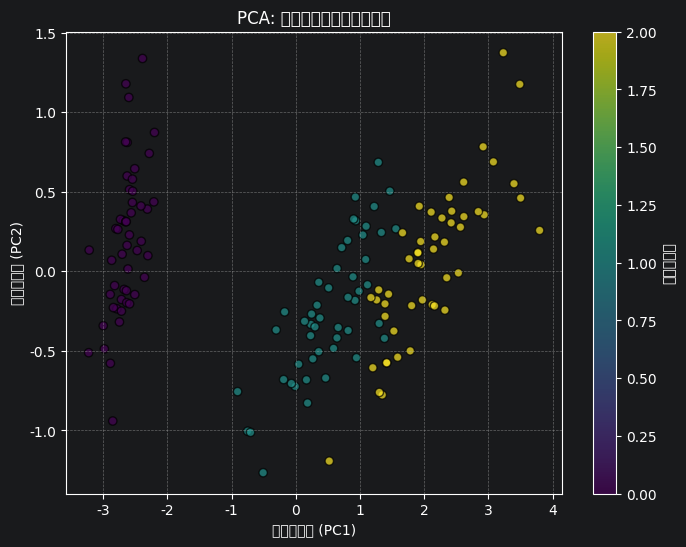

In [1]:
# 导入必要的库
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.datasets import load_iris

# -------------------------- 设置中文字体 start --------------------------
plt.rcParams['font.sans-serif'] = [
    # Windows 优先
    'SimHei', 'Microsoft YaHei',
    # macOS 优先
    'PingFang SC', 'Heiti TC',
    # Linux 优先
    'WenQuanYi Micro Hei', 'DejaVu Sans'
]
# 修复负号显示为方块的问题
plt.rcParams['axes.unicode_minus'] = False
# -------------------------- 设置中文字体 end --------------------------

# 1. 加载经典的鸢尾花数据集（4个特征）
iris = load_iris()
X = iris.data  # 原始数据：150个样本，4个特征
y = iris.target # 标签，用于可视化着色

print(f"原始数据形状: {X.shape}")  # 输出: (150, 4)

# 2. 创建PCA模型，指定降维到2维
pca = PCA(n_components=2)

# 3. 拟合模型（计算主成分）并转换数据
X_pca = pca.fit_transform(X)

print(f"降维后数据形状: {X_pca.shape}") # 输出: (150, 2)
print(f"各主成分解释的方差比例: {pca.explained_variance_ratio_}")
# 输出可能类似: [0.9246, 0.0530] 表示第一主成分保留了92.5%的信息，第二主成分保留了5.3%

# 4. 可视化降维结果
plt.figure(figsize=(8, 6))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y, edgecolor='k', alpha=0.7)
plt.xlabel('第一主成分 (PC1)')
plt.ylabel('第二主成分 (PC2)')
plt.title('PCA: 鸢尾花数据集降维可视化')
plt.colorbar(scatter, label='鸢尾花种类')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

### 4.1 代码讲解
这段代码做了三件事：
1. 先加载鸢尾花数据集，原始特征有 4 维。
2. 再用 PCA 把 4 维压缩成 2 维。
3. 最后把二维结果画成散点图，观察不同类别是否分开。

这里最值得关注的属性是 `explained_variance_ratio_`，它表示每个主成分保留了原始数据多少方差信息。这个指标越高，说明降维后保留的信息越多。

### 4.2 PCA 与 t-SNE 对比：瑞士卷数据
瑞士卷数据是一个典型的非线性流形数据。它的结构是弯曲的，如果只用线性方法 PCA 来压缩，往往会把原本卷起来的结构直接“压扁”。

t-SNE 更擅长保留局部邻域关系，因此在可视化复杂非线性结构时，通常比 PCA 更有优势。

瑞士卷数据形状: (1000, 3)


/tmp/ipykernel_91620/1586960084.py:54: UserWarning: Glyph 20027 (\N{CJK UNIFIED IDEOGRAPH-4E3B}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_91620/1586960084.py:54: UserWarning: Glyph 25104 (\N{CJK UNIFIED IDEOGRAPH-6210}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_91620/1586960084.py:54: UserWarning: Glyph 20998 (\N{CJK UNIFIED IDEOGRAPH-5206}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_91620/1586960084.py:54: UserWarning: Glyph 38477 (\N{CJK UNIFIED IDEOGRAPH-964D}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_91620/1586960084.py:54: UserWarning: Glyph 32500 (\N{CJK UNIFIED IDEOGRAPH-7EF4}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_91620/1586960084.py:54: UserWarning: Glyph 32467 (\N{CJK UNIFIED IDEOGRAPH-7ED3}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_91620/1586960084.py:54: UserWarning: Glyph 26524 (\N{CJK UNIFIED IDEOGRAP

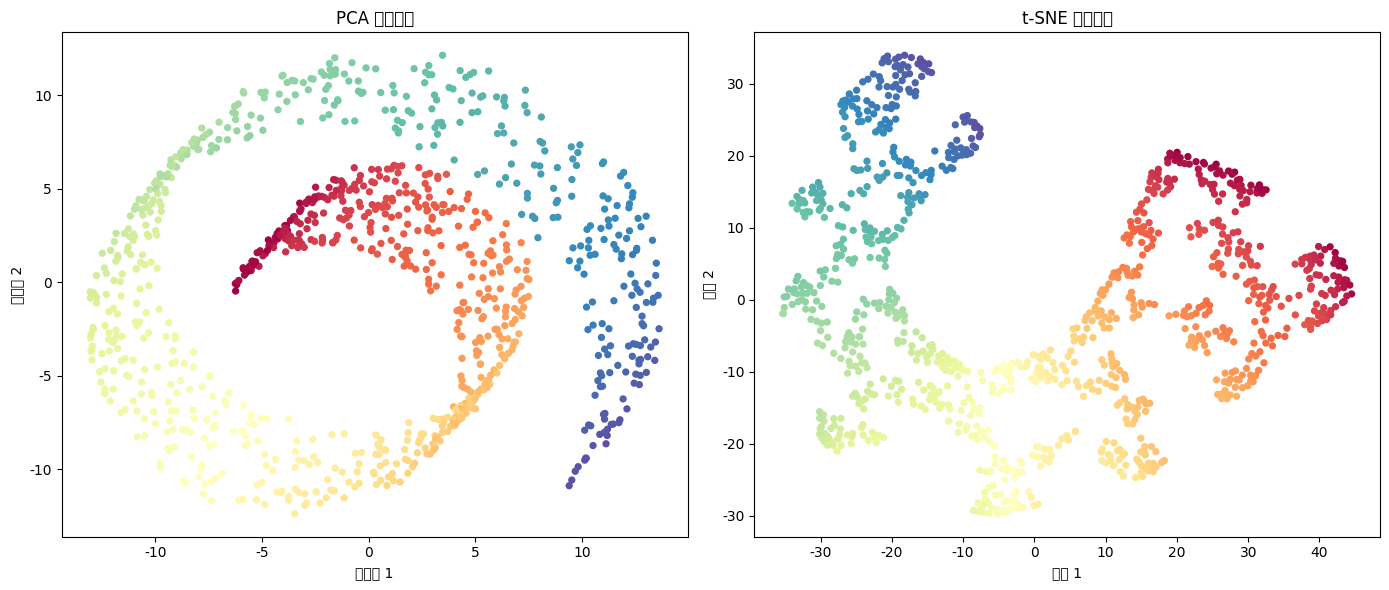

In [10]:
# 4.2 PCA 与 t-SNE 对比：瑞士卷数据
# 这一段对应网页中的“瑞士卷数据集”案例，用来观察线性方法和非线性方法的差异。

import matplotlib.pyplot as plt
from sklearn.datasets import make_swiss_roll
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

# 1. 生成一个非线性数据集：瑞士卷
X_swiss, color = make_swiss_roll(n_samples=1000, noise=0.1, random_state=42)
print(f"瑞士卷数据形状: {X_swiss.shape}")

# 2. PCA 降到二维
# PCA 适合线性结构，但对瑞士卷这种弯曲结构会丢失较多局部形态。
pca = PCA(n_components=2)
X_pca_swiss = pca.fit_transform(X_swiss)

# 3. t-SNE 降到二维
# t-SNE 关注局部邻域关系，更适合把复杂数据展开到二维进行观察。
tsne = TSNE(
    n_components=2,
    perplexity=30,
    random_state=42,
    init='pca',
    learning_rate='auto'
)
X_tsne_swiss = tsne.fit_transform(X_swiss)

# 4. 画图对比
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

scatter0 = axes[0].scatter(
    X_pca_swiss[:, 0],
    X_pca_swiss[:, 1],
    c=color,
    cmap=plt.cm.Spectral,
    s=18
)
axes[0].set_title('PCA 降维结果')
axes[0].set_xlabel('主成分 1')
axes[0].set_ylabel('主成分 2')

scatter1 = axes[1].scatter(
    X_tsne_swiss[:, 0],
    X_tsne_swiss[:, 1],
    c=color,
    cmap=plt.cm.Spectral,
    s=18
)
axes[1].set_title('t-SNE 降维结果')
axes[1].set_xlabel('维度 1')
axes[1].set_ylabel('维度 2')

plt.tight_layout()
plt.show()

# 5. 提示：如果你看到 PCA 图像被“压平”，而 t-SNE 图像仍保留了更明显的局部结构，
# 这正说明非线性降维在复杂数据可视化中的价值。

### 4.2 代码讲解
这段代码的重点有两个：
1. `make_swiss_roll` 生成的是一个弯曲的三维流形数据，适合用来测试降维算法。
2. PCA 和 t-SNE 的输出差异，可以直观看出“线性降维”和“非线性降维”对复杂数据的处理方式不同。

注意 t-SNE 的 `perplexity` 是一个非常重要的参数，通常需要通过尝试调整来观察效果。

## 5. 手写实现：PCA

下面我们不调用 `sklearn.decomposition.PCA`，而是自己写一个教学版 PCA。

这个实现会严格对应上面的数学公式：
1. 对数据做中心化
2. 计算协方差矩阵
3. 对协方差矩阵做特征值分解
4. 取前 k 个主成分
5. 将原始数据投影到新空间

你可以把这部分和前面的公式一一对应起来看。

手写 PCA 后的形状: (150, 2)
手写 PCA 的方差解释比: [0.92461872 0.05306648]
手写 PCA 的累计方差解释比: 0.9777


/home/zhiyinpeng/code/人工智能/AI-Learning/venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 25163 (\N{CJK UNIFIED IDEOGRAPH-624B}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/zhiyinpeng/code/人工智能/AI-Learning/venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 20889 (\N{CJK UNIFIED IDEOGRAPH-5199}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/zhiyinpeng/code/人工智能/AI-Learning/venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 23558 (\N{CJK UNIFIED IDEOGRAPH-5C06}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/zhiyinpeng/code/人工智能/AI-Learning/venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 40482 (\N{CJK UNIFIED IDEOGRAPH-9E22}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/zhiyinpeng/code/人工智能/AI-Learning/venv/

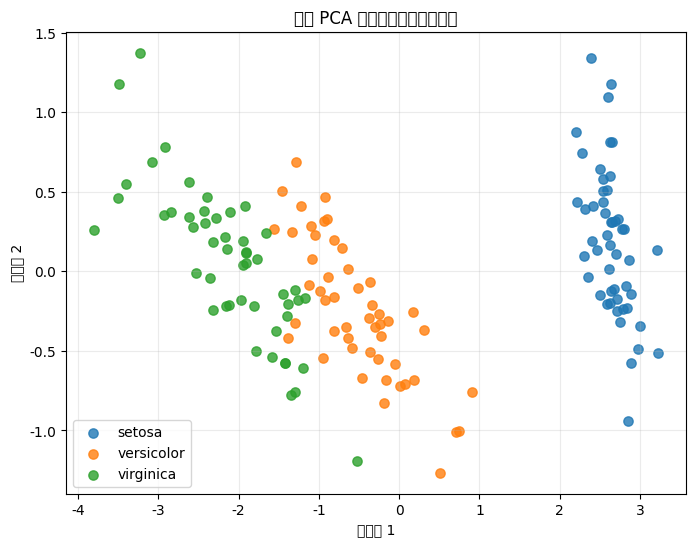


sklearn PCA 的方差解释比:
[0.92461872 0.05306648]
sklearn PCA 的累计方差解释比: 0.9777


In [11]:
# 5.1 手写 PCA
# 这份实现的目标不是追求工业级性能，而是帮助你把 PCA 的数学步骤变成可读代码。

import numpy as np
from sklearn.datasets import load_iris
import matplotlib.pyplot as plt


class ManualPCA:
    def __init__(self, n_components):
        self.n_components = n_components
        self.mean_ = None
        self.components_ = None
        self.explained_variance_ = None
        self.explained_variance_ratio_ = None

    def fit(self, X):
        # 1. 计算每个特征的均值
        # PCA 的第一步通常是中心化，也就是让每个特征减去自己的均值。
        self.mean_ = np.mean(X, axis=0)
        X_centered = X - self.mean_

        # 2. 计算协方差矩阵
        # rowvar=False 表示“每一列是一个特征”，符合机器学习常见的数据布局。
        covariance_matrix = np.cov(X_centered, rowvar=False)

        # 3. 对协方差矩阵做特征值分解
        # 协方差矩阵是对称矩阵，因此用 eigh 更合适，数值也更稳定。
        eigenvalues, eigenvectors = np.linalg.eigh(covariance_matrix)

        # 4. 按特征值从大到小排序
        # 特征值越大，说明该方向上的方差越大，也越重要。
        sorted_indices = np.argsort(eigenvalues)[::-1]
        eigenvalues = eigenvalues[sorted_indices]
        eigenvectors = eigenvectors[:, sorted_indices]

        # 5. 取前 n_components 个主成分
        self.components_ = eigenvectors[:, : self.n_components]
        self.explained_variance_ = eigenvalues[: self.n_components]
        self.explained_variance_ratio_ = self.explained_variance_ / np.sum(eigenvalues)
        return self

    def transform(self, X):
        # 6. 将中心化后的数据投影到主成分方向上
        X_centered = X - self.mean_
        return np.dot(X_centered, self.components_)

    def fit_transform(self, X):
        # 训练和转换一步完成，方便实际使用
        self.fit(X)
        return self.transform(X)


# 5.2 使用手写 PCA 处理鸢尾花数据
# 这里的特征数是 4，我们把它压缩到 2 维，和前面的 sklearn 示例保持一致，方便对比。
iris = load_iris()
X = iris.data
y = iris.target

manual_pca = ManualPCA(n_components=2)
X_manual_pca = manual_pca.fit_transform(X)

print(f"手写 PCA 后的形状: {X_manual_pca.shape}")
print(f"手写 PCA 的方差解释比: {manual_pca.explained_variance_ratio_}")
print(f"手写 PCA 的累计方差解释比: {manual_pca.explained_variance_ratio_.sum():.4f}")

# 5.3 绘图
plt.figure(figsize=(8, 6))
for target_value, target_name in enumerate(iris.target_names):
    mask = y == target_value
    plt.scatter(
        X_manual_pca[mask, 0],
        X_manual_pca[mask, 1],
        label=target_name,
        alpha=0.8,
        s=45
    )

plt.title('手写 PCA 将鸢尾花数据降到二维')
plt.xlabel('主成分 1')
plt.ylabel('主成分 2')
plt.legend()
plt.grid(alpha=0.25)
plt.show()

# 5.4 与 sklearn PCA 对比
# 两者的方向可能只差一个正负号，这是正常现象。
# 只要投影后的结构相似，就说明手写实现和库实现思路是一致的。
from sklearn.decomposition import PCA

sklearn_pca = PCA(n_components=2)
X_sklearn_pca = sklearn_pca.fit_transform(X)

print('\nsklearn PCA 的方差解释比:')
print(sklearn_pca.explained_variance_ratio_)
print(f"sklearn PCA 的累计方差解释比: {sklearn_pca.explained_variance_ratio_.sum():.4f}")

## 6. 实践练习与总结

### 6.1 MNIST 降维练习
下面这段代码对应网页里的实践部分：先把图像数据压缩到较低维度，再进一步用 t-SNE 做可视化。为了避免长时间卡住，这里默认使用更小的样本数，并在网络不可用时回退到本地数据集。

如果你想严格复现网页中的 MNIST 版本，可以把样本数再调大，但运行时间也会更长。

原始数据形状: (1797, 64)
PCA 后形状: (1797, 20)
PCA 累计解释方差比: 0.7931


/home/zhiyinpeng/code/人工智能/AI-Learning/venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 32500 (\N{CJK UNIFIED IDEOGRAPH-7EF4}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/zhiyinpeng/code/人工智能/AI-Learning/venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 24230 (\N{CJK UNIFIED IDEOGRAPH-5EA6}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/zhiyinpeng/code/人工智能/AI-Learning/venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 25968 (\N{CJK UNIFIED IDEOGRAPH-6570}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/zhiyinpeng/code/人工智能/AI-Learning/venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 25454 (\N{CJK UNIFIED IDEOGRAPH-636E}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/zhiyinpeng/code/人工智能/AI-Learning/venv/

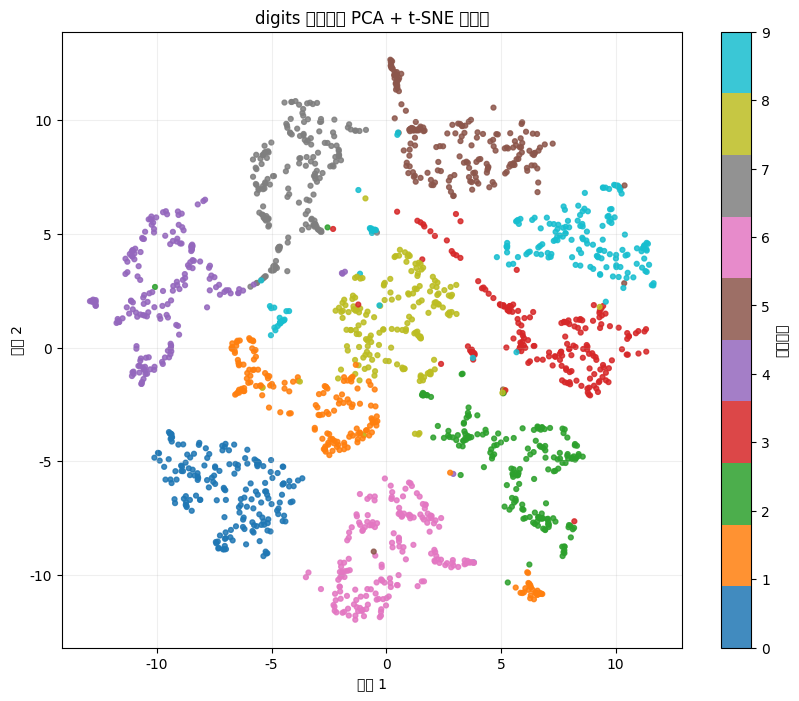

In [12]:
# 6.1 MNIST 降维练习（稳定版）
# 原始的 MNIST 下载 + t-SNE 很容易因为网络和计算量而卡住，
# 所以这里改成本地可直接运行的 digits 数据集，流程和网页里的“先 PCA，再 t-SNE”保持一致。

from sklearn.datasets import load_digits
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

# 1. 使用本地 digits 数据集，避免网络下载导致卡住
# digits 也是手写数字数据集，维度更小，适合教学演示。
digits = load_digits()
X_mnist = digits.data
y_mnist = digits.target.astype(str)

print(f"原始数据形状: {X_mnist.shape}")

# 2. 标准化
# 每个特征先做标准化，避免不同像素尺度差异影响 PCA。
X_mnist = StandardScaler().fit_transform(X_mnist)

# 3. 先用 PCA 压缩到较低维度
# 这里不需要压得太高，20 维通常足够保留主要结构，同时让 t-SNE 更快。
pca = PCA(n_components=20, random_state=42)
X_mnist_pca = pca.fit_transform(X_mnist)
print(f"PCA 后形状: {X_mnist_pca.shape}")
print(f"PCA 累计解释方差比: {pca.explained_variance_ratio_.sum():.4f}")

# 4. 再用 t-SNE 压缩到 2 维
# 为了避免长时间运行，这里减少迭代次数，并把 perplexity 设得更保守一些。
tsne = TSNE(
    n_components=2,
    perplexity=15,
    random_state=42,
    init='pca',
    learning_rate='auto',
    max_iter=300,
    n_iter_without_progress=100
)
X_mnist_tsne = tsne.fit_transform(X_mnist_pca)

# 5. 绘图
plt.figure(figsize=(10, 8))
scatter = plt.scatter(
    X_mnist_tsne[:, 0],
    X_mnist_tsne[:, 1],
    c=digits.target,
    cmap='tab10',
    s=12,
    alpha=0.85
)
plt.title('digits 数据集的 PCA + t-SNE 可视化')
plt.xlabel('维度 1')
plt.ylabel('维度 2')
plt.colorbar(scatter, label='数字类别')
plt.grid(alpha=0.2)
plt.show()

# 6. 如果你后面想严格复现网页中的 MNIST 版本，可以单独再开一个单元运行 fetch_openml 版。